In [1]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cortex as cx

from prf_expect.utils import io
from prf_expect.utils.viz import desaturate_palette, sample_cmap, cm_to_inch


def load_pred_file(subject, space, condition, run, pred_dir):
    """Load one prediction file for a subject/condition/run with flexible run matching."""
    pred_dir = Path(pred_dir)
    run_str = str(run)
    run_digits_match = re.search(r"(\d+)", run_str)
    run_digits = int(run_digits_match.group(1)) if run_digits_match else None

    files = sorted(
        glob.glob(
            str(pred_dir / f"{subject}_ses-1_task-{condition}_*space-{space}*pred*.npy")
        )
    )
    if not files:
        raise FileNotFoundError(
            f"No prediction files found for subject={subject}, condition={condition}, space={space} in {pred_dir}"
        )

    if run_digits is not None:
        run_tokens = [
            f"run-{run_digits:02d}",
            f"run-{run_digits}",
            f"_{run_str}_",
        ]
        matched = [f for f in files if any(tok in Path(f).name for tok in run_tokens)]
        if len(matched) == 1:
            return np.load(matched[0], allow_pickle=True)
        if len(matched) > 1:
            exact = [f for f in matched if f"run-{run_digits:02d}" in Path(f).name]
            return np.load((exact[0] if exact else matched[0]), allow_pickle=True)

    if len(files) == 1:
        return np.load(files[0], allow_pickle=True)

    raise FileNotFoundError(
        f"Could not uniquely resolve run={run} for subject={subject}, condition={condition}. Candidates: {[Path(f).name for f in files]}"
    )


def calculate_rsq_reference(target, prediction):
    """Compute voxel-wise R^2 using `target` as reference and `prediction` as model output."""
    ss_res = np.sum((target - prediction) ** 2, axis=1)
    ss_tot = np.sum((target - np.mean(target, axis=1, keepdims=True)) ** 2, axis=1)
    rsq = np.full(target.shape[0], np.nan, dtype=float)
    valid = ss_tot > 0
    rsq[valid] = 1 - (ss_res[valid] / ss_tot[valid])
    return rsq

# R² vs matched noise across omission/sparse/violation
This notebook simulates signal-to-noise effects by adding the same absolute noise level to model predictions from all three conditions (omission, sparse, violation).
R² is computed against the original prediction itself as the target reference, then summarized across ROIs.

In [2]:
# User-configurable parameters
settings = io.load_settings()
data_dir = Path(settings["general"]["data_dir"]) / "data"
space = settings["mri"]["space"]
pe_runs = settings["design"]["runs_per_task"]

subjects = ["sub-001", "sub-002", "sub-004", "sub-005", "sub-007", "sub-009", "sub-012"]
conditions = ("omission", "sparse", "violation")

# Combined ROI definitions (same convention used in your other notebooks)
roi_names_long = (
    "V1", "V2", "V3", "V3A", "V3B", "V4",
    "LO1", "LO2", "VO1", "VO2",
    "hMT", "MST",
    "IPS0", "IPS1", "IPS2", "IPS3", "IPS4", "IPS5"
 )
roi_verts_long = cx.get_roi_verts("fsaverage", roi_names_long)
rois = {
    "V1": roi_verts_long["V1"],
    "V2": roi_verts_long["V2"],
    "V3": roi_verts_long["V3"],
    "V3AB": np.concatenate((roi_verts_long["V3A"], roi_verts_long["V3B"])),
    "V4": roi_verts_long["V4"],
    "LO": np.concatenate((roi_verts_long["LO1"], roi_verts_long["LO2"])),
    "TO": np.concatenate((roi_verts_long["hMT"], roi_verts_long["MST"])),
    "VO": np.concatenate((roi_verts_long["VO1"], roi_verts_long["VO2"])),
    "earlyIPS": np.concatenate((roi_verts_long["IPS0"], roi_verts_long["IPS1"], roi_verts_long["IPS2"])),
    "lateIPS": np.concatenate((roi_verts_long["IPS3"], roi_verts_long["IPS4"], roi_verts_long["IPS5"]))
}

# Noise levels are fractions of a shared signal scale within each subject/ROI
noise_fracs = np.array([0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00])
n_noise_repeats = 40
rng = np.random.default_rng(42)

# Voxel selection criteria
nr_best_voxels = 200
param_r2_threshold = 0.0

print(f"Data dir: {data_dir}")
print(f"Subjects: {subjects}")
print(f"ROIs: {list(rois.keys())}")

Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Data dir: /Users/dionysus/Downloads/data
Subjects: ['sub-001', 'sub-002', 'sub-004', 'sub-005', 'sub-007', 'sub-009', 'sub-012']
ROIs: ['V1', 'V2', 'V3', 'V3AB', 'V4', 'LO', 'TO', 'VO', 'earlyIPS', 'lateIPS']


In [3]:
records = []

for subject in subjects:
    print(f"Processing {subject}...")
    sub_dir = data_dir / "derivatives" / "prf_data" / subject / "ses-1"
    prf_fits_dir = sub_dir / "prf_fits"
    prf_params_dir = prf_fits_dir / "prf_params"
    pred_dir = prf_fits_dir / "prf_predictions"

    params_tsv = prf_params_dir / f"{subject}_ses-1_final-fit_space-{space}_model-norm_stage-iter_desc-prf_params.tsv"
    prf_params_all = pd.read_csv(params_tsv, sep="\t")

    # Load and concatenate precomputed predictions across PE runs per condition
    preds_by_cond_runs = {cond: [] for cond in conditions}
    for run in pe_runs:
        for cond in conditions:
            pred_run = load_pred_file(subject, space, cond, run, pred_dir)
            preds_by_cond_runs[cond].append(pred_run)

    preds_by_cond = {
        cond: np.concatenate(preds_by_cond_runs[cond], axis=1)
        for cond in conditions
    }

    for roi_name, roi_indices in rois.items():
        if len(roi_indices) == 0:
            continue

        roi_params = prf_params_all.iloc[roi_indices].copy()
        if "r2" in roi_params.columns:
            roi_params = roi_params[roi_params["r2"] > param_r2_threshold]
            roi_params = roi_params.sort_values(by="r2", ascending=False)
        if roi_params.empty:
            continue

        if len(roi_params) > nr_best_voxels:
            roi_params = roi_params.head(nr_best_voxels)

        best_voxel_indices = roi_params.index.to_numpy()

        # Guard against index mismatch between parameter table and prediction arrays
        n_vertices_pred = preds_by_cond[conditions[0]].shape[0]
        best_voxel_indices = best_voxel_indices[best_voxel_indices < n_vertices_pred]
        if best_voxel_indices.size == 0:
            continue

        preds_roi = {cond: preds_by_cond[cond][best_voxel_indices] for cond in conditions}

        # Same absolute noise magnitude across omission/sparse/violation
        pooled_pred = np.concatenate([preds_roi[c].ravel() for c in conditions])
        base_scale = np.nanstd(pooled_pred)
        if not np.isfinite(base_scale) or base_scale == 0:
            continue

        for noise_frac in noise_fracs:
            noise_std = noise_frac * base_scale
            for rep in range(n_noise_repeats):
                for cond in conditions:
                    pred = preds_roi[cond]
                    noise = rng.normal(0, noise_std, size=pred.shape)
                    pred_noisy = pred + noise

                    rsq_vox = calculate_rsq_reference(pred, pred_noisy)
                    rsq_vox = rsq_vox[np.isfinite(rsq_vox)]
                    if rsq_vox.size == 0:
                        continue

                    records.append(
                        {
                            "subject": subject,
                            "roi": roi_name,
                            "condition": cond,
                            "noise_frac": float(noise_frac),
                            "noise_std": float(noise_std),
                            "repeat": rep,
                            "n_vox": int(rsq_vox.size),
                            "rsq_mean": float(np.mean(rsq_vox)),
                            "rsq_median": float(np.median(rsq_vox)),
                        }
                    )

df_rsq_noise = pd.DataFrame.from_records(records)
print(f"Simulation finished with {len(df_rsq_noise)} rows.")
df_rsq_noise.head()

Processing sub-001...
Processing sub-002...
Processing sub-004...
Processing sub-005...
Processing sub-007...
Processing sub-009...
Processing sub-012...
Simulation finished with 92400 rows.


,subject,roi,condition,noise_frac,noise_std,repeat,n_vox,rsq_mean,rsq_median
0,sub-001,V1,omission,0.0,0.0,0,200,1.0,1.0
1,sub-001,V1,sparse,0.0,0.0,0,200,1.0,1.0
2,sub-001,V1,violation,0.0,0.0,0,200,1.0,1.0
3,sub-001,V1,omission,0.0,0.0,1,200,1.0,1.0
4,sub-001,V1,sparse,0.0,0.0,1,200,1.0,1.0


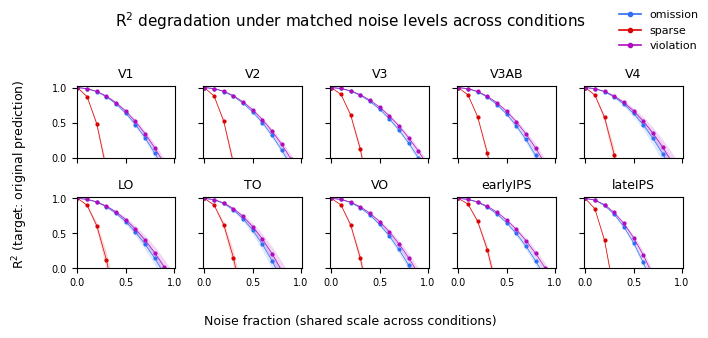

In [4]:
# Aggregate across repeats per subject to avoid pseudo-replication in group summaries
df_sub = (
    df_rsq_noise
    .groupby(["subject", "roi", "condition", "noise_frac"], as_index=False)["rsq_mean"]
    .mean()
    .rename(columns={"rsq_mean": "rsq_subject_mean"})
)

roi_order = list(rois.keys())
cond_order = ["omission", "sparse", "violation"]
cond_colors = {
    "omission": "#306EF6",
    "sparse": "#d90202",
    "violation": "#b20bbd",
}

n_rois = len(roi_order)
ncols = 5
nrows = int(np.ceil(n_rois / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=cm_to_inch(18, 8), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for i, roi_name in enumerate(roi_order):
    ax = axes[i]
    d_roi = df_sub[df_sub["roi"] == roi_name]
    if d_roi.empty:
        ax.set_title(f"{roi_name} (no data)", fontsize=9)
        ax.axis("off")
        continue

    for cond in cond_order:
        d_cond = d_roi[d_roi["condition"] == cond]
        if d_cond.empty:
            continue

        xvals = np.sort(d_cond["noise_frac"].unique())
        means, sems = [], []
        for x in xvals:
            vals = d_cond.loc[d_cond["noise_frac"] == x, "rsq_subject_mean"].to_numpy()
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                means.append(np.nan)
                sems.append(np.nan)
            else:
                means.append(np.mean(vals))
                sems.append(np.std(vals, ddof=1) / np.sqrt(vals.size) if vals.size > 1 else 0.0)

        means = np.array(means, dtype=float)
        sems = np.array(sems, dtype=float)

        ax.plot(xvals, means, marker="o", markersize=2, lw=0.5, color=cond_colors[cond], label=cond)
        ax.fill_between(xvals, means - sems, means + sems, color=cond_colors[cond], alpha=0.16, lw=0)

    ax.axhline(0, color="0.7", ls="--", lw=0.7)
    ax.set_title(roi_name, fontsize=9)
    ax.set_xlim(noise_fracs.min() - 0.01, noise_fracs.max() + 0.01)
    ax.set_ylim(0, 1.02)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.supxlabel("Noise fraction (shared scale across conditions)", fontsize=9)
fig.supylabel("R$^2$ (target: original prediction)", fontsize=9)
handles = [plt.Line2D([0], [0], color=cond_colors[c], lw=1.2, marker="o", markersize=3, label=c) for c in cond_order]
fig.legend(handles=handles, labels=cond_order, frameon=False, fontsize=8)
fig.suptitle("R$^2$ degradation under matched noise levels across conditions", y=1.02, fontsize=11)
fig.tight_layout()
plt.show()
fig.savefig("prf_prediction_SNR_simulation.png", dpi=300, bbox_inches="tight")

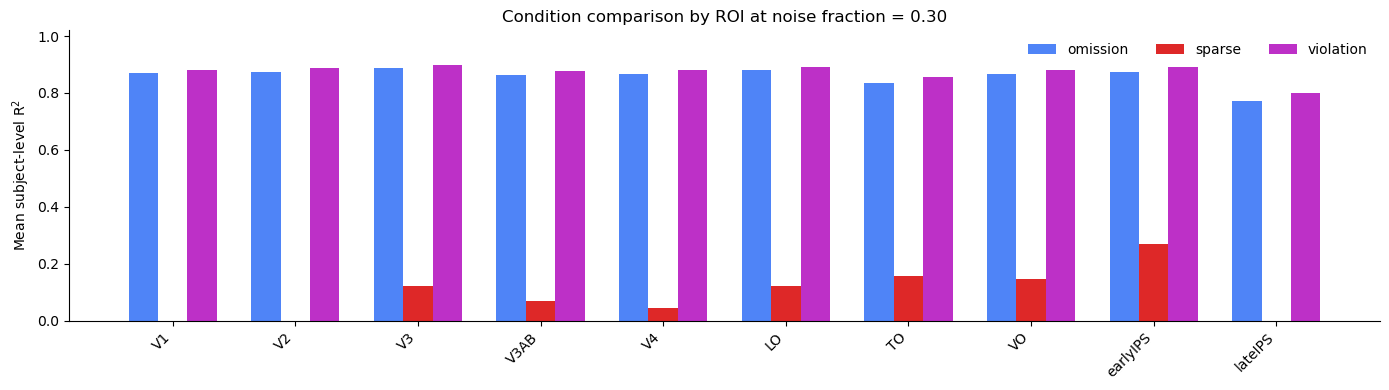

In [5]:
# Optional: condition comparison at one representative noise level
noise_level_for_bar = 0.30
d_focus = df_sub[np.isclose(df_sub["noise_frac"], noise_level_for_bar)].copy()

if d_focus.empty:
    print(f"No rows found for noise_frac={noise_level_for_bar:.2f}")
else:
    roi_means = (
        d_focus
        .groupby(["roi", "condition"], as_index=False)["rsq_subject_mean"]
        .mean()
    )

    x = np.arange(len(roi_order))
    width = 0.24

    fig, ax = plt.subplots(figsize=(14, 4))
    for i, cond in enumerate(cond_order):
        d_cond = roi_means[roi_means["condition"] == cond].set_index("roi").reindex(roi_order)
        y = d_cond["rsq_subject_mean"].to_numpy()
        ax.bar(x + (i - 1) * width, y, width=width, color=cond_colors[cond], alpha=0.85, label=cond)

    ax.set_xticks(x)
    ax.set_xticklabels(roi_order, rotation=45, ha="right")
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("Mean subject-level R$^2$")
    ax.set_title(f"Condition comparison by ROI at noise fraction = {noise_level_for_bar:.2f}")
    ax.legend(frameon=False, ncol=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    plt.show()